### Introduction to Artificial Intelligence
## Lab 05 Tasks
This lab covers UCS and Informed Searches.

#### Section I
* Uniform Cost Search
####  Section II
Informed Searches
* Greedy Best-First Search
* A* search

**Lab Outcomes**
* Explain Uniform Cost Search (UCS), Greedy Best-First Search (GBFS) and A*.
* Distinguish between g(n), h(n) and f(n).
* Implement the algorithms using basic Python data structures.
* Use Python's heapq priority queue to implement efficient versions.
* Compare the paths and costs produced by the three algorithms.

**Exercise:**
For the map of Romania given below \

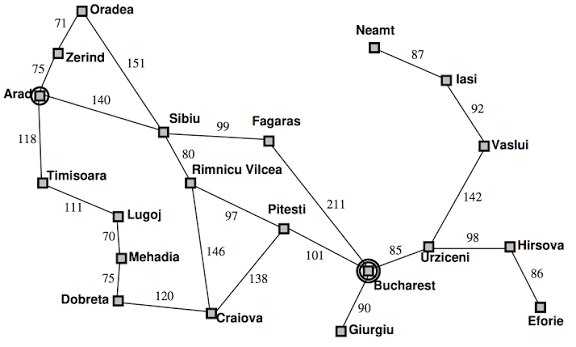

Extract your graph from Arad to Bucharest as per instruction given in lab (with and without heapq)
Calculate the paths and costs by 
* UCS
* Greedy Best-First Search
* A*

In [3]:
class Node:
    def __init__(self, s, p, c):
        self.state = s
        self.parent = p
        self.cost = c

    def get_path(self):
        path = []
        current = self

        while current is not None:
            path.append(current.state)
            current = current.parent

        path.reverse()
        return path

graph = {
    'Arad': [('Sibui', 140)],
    'Sibui': [('Fagaras', 99), ('Rimnicu', 80)],
    'Fagaras': [('Bucharest', 211)],
    'Bucharest': [],
    'Rimnicu': [('Pitesti', 97)],
    'Pitesti': [('Bucharest', 101)],
    }

def usc(start, goal):
    startNode = Node(start, None, 0)

    frontier = [startNode]

    while frontier:
        frontier.sort(key=lambda node: node.cost)

        current = frontier.pop(0)

        print(f'Visiting the city {current.state}: cost: {current.cost}')

        if current.state == goal:
            return current

        for neighbour, edge_cost in graph[current.state]:
            new_cost = current.cost + edge_cost
            child = Node(
                neighbour,
                current,
                new_cost,
            )

            frontier.append(child)
            
    return None

In [4]:
solution = usc('Arad', 'Bucharest')

print('Path: ', solution.get_path())
print('Cost: ', solution.cost)

Visiting the city Arad: cost: 0
Visiting the city Sibui: cost: 140
Visiting the city Rimnicu: cost: 220
Visiting the city Fagaras: cost: 239
Visiting the city Pitesti: cost: 317
Visiting the city Bucharest: cost: 418
Path:  ['Arad', 'Sibui', 'Rimnicu', 'Pitesti', 'Bucharest']
Cost:  418


**Exercise:**
Solve the any 1 of the mazes provided in the text files assuming each block costs 1.

Calculate the path cost and return paths by
* UCS
* Greedy Best-First Search
* A*

In [17]:
graph_1 = {
    'A': [('B', 3), ('C', 2)],
    'B': [('D', 4)],
    'C': [('D', 1)],
    'D': []
}

heuristic_1 = {
    'A': 5,
    'B': 3,
    'C': 1,
    'D': 0
}

In [18]:
class Node:
    def __init__(self, state, parent=None, cost=0):
        self.state = state
        self.parent = parent
        self.cost = cost

    def get_path(self):
        path = []
        current = self
        while current is not None:
            path.append(current.state)
            current = current.parent
        path.reverse()
        return path

def greedy_bfs(start, goal):
    start_node = Node(start)
    frontier = [start_node]

    while frontier:
        frontier.sort(key=lambda node: heuristic_1[node.state])
        current = frontier.pop(0)

        print("Visiting:", current.state, "h =", heuristic_1[current.state])

        if current.state == goal:
            return current

        for neighbor, edge_cost in graph_1[current.state]:
            child = Node(
                neighbor,
                current,
                current.cost + edge_cost
            )
            frontier.append(child)

    return None

solution = greedy_bfs('A', 'D')

print("Path:", solution.get_path())
print("Cost:", solution.cost)

Visiting: A h = 5
Visiting: C h = 1
Visiting: D h = 0
Path: ['A', 'C', 'D']
Cost: 3


**Marking Criteria**
For each question with marks 20, the marking will be done according to the following criteria. 

| Component | Marks |
| :--- | :---: |
| UCS | 5 |
| GBFS | 5 |
| A* | 5 |
| Solved & Dry Run | 5 |


In [16]:
import heapq

class Node:
    def __init__(self, state, parent=None, cost=0):
        self.state = state
        self.parent = parent
        self.cost = cost

    def get_path(self):
        path = []
        current = self
        while current is not None:
            path.append(current.state)
            current = current.parent
        path.reverse()
        return path

graph = {
    'Arad': [('Sibiu', 140)],
    'Sibiu': [('Fagaras', 99), ('Rimnicu', 80)],
    'Fagaras': [('Bucharest', 211)],
    'Rimnicu': [('Pitesti', 97)],
    'Pitesti': [('Bucharest', 101)],
    'Bucharest': []
}

heuristic = {
    'Arad': 366,
    'Sibiu': 253,
    'Fagaras': 176,
    'Rimnicu': 193,
    'Pitesti': 100,
    'Bucharest': 0
}

# 1. Uniform Cost Search (UCS)
def ucs(start, goal):
    start_node = Node(start, None, 0)
    frontier = []
    heapq.heappush(frontier, (0, start_node.state, start_node))
    explored = set()

    while frontier:
        cost, state, current = heapq.heappop(frontier)
        if current.state == goal:
            return current
        if current.state in explored:
            continue
        explored.add(current.state)

        for neighbor, edge_cost in graph.get(current.state, []):
            if neighbor not in explored:
                child = Node(neighbor, current, current.cost + edge_cost)
                heapq.heappush(frontier, (child.cost, child.state, child))
    return None

# 2. Greedy Best-First Search (GBFS)
def greedy_bfs(start, goal):
    start_node = Node(start, None, 0)
    frontier = []
    heapq.heappush(frontier, (heuristic[start], start_node.state, start_node))
    explored = set()

    while frontier:
        h, state, current = heapq.heappop(frontier)
        if current.state == goal:
            return current
        if current.state in explored:
            continue
        explored.add(current.state)

        for neighbor, edge_cost in graph.get(current.state, []):
            if neighbor not in explored:
                child = Node(neighbor, current, current.cost + edge_cost)
                heapq.heappush(frontier, (heuristic[neighbor], child.state, child))
    return None

# 3. A* Search
def astar(start, goal):
    start_node = Node(start, None, 0)
    frontier = []
    heapq.heappush(frontier, (heuristic[start], start_node.state, start_node))
    explored = set()

    while frontier:
        f, state, current = heapq.heappop(frontier)
        if current.state == goal:
            return current
        if current.state in explored:
            continue
        explored.add(current.state)

        for neighbor, edge_cost in graph.get(current.state, []):
            if neighbor not in explored:
                child = Node(neighbor, current, current.cost + edge_cost)
                f_cost = child.cost + heuristic[neighbor]
                heapq.heappush(frontier, (f_cost, child.state, child))
    return None

sol_ucs = ucs('Arad', 'Bucharest')
print(f"UCS Path: {sol_ucs.get_path()}, Cost: {sol_ucs.cost}")

sol_gbfs = greedy_bfs('Arad', 'Bucharest')
print(f"GBFS Path: {sol_gbfs.get_path()}, Cost: {sol_gbfs.cost}")

sol_astar = astar('Arad', 'Bucharest')
print(f"A* Path: {sol_astar.get_path()}, Cost: {sol_astar.cost}")

UCS Path: ['Arad', 'Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest'], Cost: 418
GBFS Path: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest'], Cost: 450
A* Path: ['Arad', 'Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest'], Cost: 418


In [15]:
import heapq

class MazeNode:
    def __init__(self, state, parent=None, cost=0):
        self.state = state
        self.parent = parent
        self.cost = cost

    def get_path(self):
        path = []
        current = self
        while current is not None:
            path.append(current.state)
            current = current.parent
        path.reverse()
        return path

def parse_maze(filename):
    grid = []
    with open(filename, 'r') as f:
        for line in f:
            grid.append(list(line.rstrip('\n')))
    
    start = None
    goal = None
    rows = len(grid)
    cols = max(len(r) for r in grid)
    
    for r in range(rows):
        for c in range(len(grid[r])):
            if grid[r][c] == 'A':
                start = (r, c)
            elif grid[r][c] == 'B':
                goal = (r, c)
                
    return grid, start, goal

def get_neighbors(state, grid):
    r, c = state
    neighbors = []
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]
    rows = len(grid)
    
    for dr, dc in directions:
        nr, nc = r + dr, c + dc
        if 0 <= nr < rows and 0 <= nc < len(grid[nr]):
            if grid[nr][nc] != '#':
                neighbors.append(((nr, nc), 1))
    return neighbors

def manhattan_distance(state, goal):
    return abs(state[0] - goal[0]) + abs(state[1] - goal[1])

def maze_ucs(filename):
    grid, start, goal = parse_maze(filename)
    start_node = MazeNode(start, None, 0)
    frontier = []
    heapq.heappush(frontier, (0, start_node.state, start_node))
    explored = set()

    while frontier:
        cost, state, current = heapq.heappop(frontier)

        if current.state == goal:
            return current

        if current.state in explored:
            continue
        explored.add(current.state)

        for neighbor, edge_cost in get_neighbors(current.state, grid):
            if neighbor not in explored:
                child = MazeNode(neighbor, current, current.cost + edge_cost)
                heapq.heappush(frontier, (child.cost, child.state, child))

    return None

def maze_gbfs(filename):
    grid, start, goal = parse_maze(filename)
    start_node = MazeNode(start, None, 0)
    frontier = []
    heapq.heappush(frontier, (manhattan_distance(start, goal), start_node.state, start_node))
    explored = set()

    while frontier:
        h, state, current = heapq.heappop(frontier)

        if current.state == goal:
            return current

        if current.state in explored:
            continue
        explored.add(current.state)

        for neighbor, edge_cost in get_neighbors(current.state, grid):
            if neighbor not in explored:
                child = MazeNode(neighbor, current, current.cost + edge_cost)
                priority = manhattan_distance(neighbor, goal)
                heapq.heappush(frontier, (priority, child.state, child))

    return None

def maze_astar(filename):
    grid, start, goal = parse_maze(filename)
    start_node = MazeNode(start, None, 0)
    frontier = []
    heapq.heappush(frontier, (manhattan_distance(start, goal), start_node.state, start_node))
    explored = set()

    while frontier:
        f, state, current = heapq.heappop(frontier)

        if current.state == goal:
            return current

        if current.state in explored:
            continue
        explored.add(current.state)

        for neighbor, edge_cost in get_neighbors(current.state, grid):
            if neighbor not in explored:
                child = MazeNode(neighbor, current, current.cost + edge_cost)
                new_f = child.cost + manhattan_distance(neighbor, goal)
                heapq.heappush(frontier, (new_f, child.state, child))

    return None

solution = maze_astar('maze3.txt')
if solution:
    print("Maze Path:", solution.get_path())
    print("Maze Cost:", solution.cost)

Maze Path: [(5, 0), (4, 0), (4, 1), (3, 1), (2, 1)]
Maze Cost: 4
